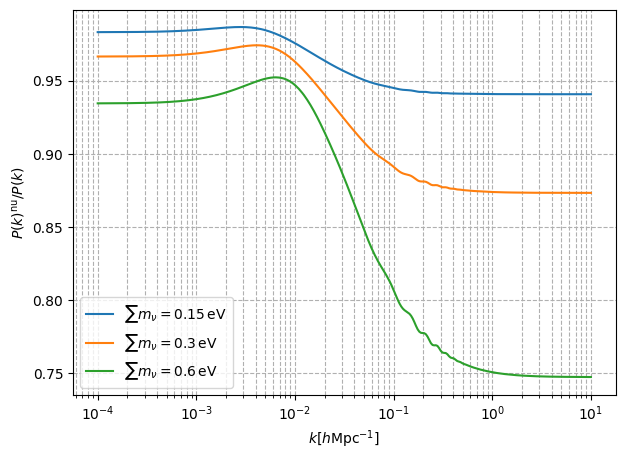

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.optimize import fsolve


common_settings = {
'output': 'mPk',

}

z = 0.0
h = 0.67742
k = np.logspace(-4, 1, 300)  # h/Mpc
kmax_1_over_Mpc = k.max() * h
pk_cb_massless = []
pk_cb_massive = []

plt.figure(figsize=(7,5))

cosmo_massless = Class()

params_massless = common_settings.copy()
params_massless.update({
    'Omega_k':0.0,
    'Omega_b':0.0488911,
    'Omega_cdm':0.3099-0.0488911,
    'h':0.67742,
    'A_s':2.65e-09,
    'n_s':0.96822,
    'gauge':'synchronous',
    'reio_parametrization' : 'reio_none',
    'k_per_decade_for_pk' : 100,
    'k_per_decade_for_bao' : 100,
    'T_cmb':2.7255,
    'YHe':0.248,
    'output':'mPk,mTk,vTk',
    'P_k_max_1/Mpc': 1.01 * kmax_1_over_Mpc,
    'z_max_pk':1000.0,
    'recombination' : 'RECFAST',
    'l_max_g' : 31,
    'l_max_pol_g' : 31,
    'l_max_ur' : 31,
    'l_max_ncdm' : 31,
    'Omega_Lambda' : 0.0,
    'w0_fld' : -0.99,
    'wa_fld' : 0,
    'cs2_fld' : 1.0,
    'use_ppf' : 'no',
    'radiation_streaming_approximation' : 2,
    'ncdm_fluid_approximation' : 3,
    'ur_fluid_approximation' : 2,
    'N_ur': 2.046,
    'N_ncdm': 1,
    'm_ncdm': 1e-10

})

cosmo_massless.set(params_massless)
cosmo_massless.compute()

for ki in k:
    k_class = ki * 0.67742
    pk1 = cosmo_massless.pk_cb(k_class, z) 
    pk_cb_massless.append(pk1)

pk_cb_massless = np.array(pk_cb_massless)

h = 0.67742
Pk_massless_hunits = pk_cb_massless * h**3
np.savetxt(
"Pk_cb_massless_z0.txt",
np.column_stack([k, Pk_massless_hunits]),
header="k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, massless neutrinos)"
)


results_class = []

for sum_masses in [0.15, 0.3, 0.6]:

    cosmo_massive = Class()

    pk_cb_massive = []

    params_massive = params_massless.copy()
    params_massive.update({
        'Omega_cdm':0.3099-0.0488911,#-(sum_masses/(93.14*0.67742**2)),
        'N_ncdm': 1, 'deg_ncdm': 1, 'm_ncdm': sum_masses, 'N_ur': 2.046
    })

    cosmo_massive.set(params_massive)
    cosmo_massive.compute()

    for ki in k:
        k_class = ki * 0.67742
        pk2 = cosmo_massive.pk_cb(k_class, z) 
        pk_cb_massive.append(pk2)

    pk_cb_massive = np.array(pk_cb_massive)

  
    Pk_massive_hunits = pk_cb_massive * h**3
    fname = f"Pk_cb_sumMnu_{sum_masses:.2f}eV_z0.txt"
    np.savetxt(
        fname,
        np.column_stack([k, Pk_massive_hunits]),
        header=f"k[h/Mpc]    Pk[Mpc^3/h^3] (CDM+baryons, z=0, sum m_nu = {sum_masses} eV)"
    )

    ratio = pk_cb_massive / pk_cb_massless

    plt.semilogx(
        k,
        ratio,
        label=rf'$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$'
    )
    results_class.append({
        "k": k,
        "ratio": ratio,
        "mass": sum_masses,
        "method": "CLASS"
    })
    cosmo_massive.struct_cleanup()
    cosmo_massive.empty()


plt.xlabel(r'$k [h \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^\mathrm{nu}/P(k)$')
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)

np.save("class_results.npy", results_class)

cosmo_massless.struct_cleanup()
cosmo_massless.empty()